# Minor Flood Frequency


```{glue:figure} fig-threshold_counts_enso
:name: fig-threshold_counts_enso
:align: left
:scale: 50%
```


In this notebook we will plot two indicators concerning flooding at the {glue:text}`station` tide gauge, after first taking a general look at the type of data we are able to plot from the [UH Sea Level Center](https://uhslc.soest.hawaii.edu/stations/?stn=007#levels). These indicators are based on a 'flooding' threshold, using [relative sea level](https://tidesandcurrents.noaa.gov/sltrends/faq.html). 

<!-- Download Files: -->
<!-- [Map](../output/SL_FloodFrequency_map.png) |
[Time Series Plot](../output/SL_FloodFrequency_threshold_counts_days.png) |
[Table](../output/SL_FloodFrequency_percent_change.csv) -->


## Setup

We first need to import the necessary libraries, access the data, and make a quick plot to ensure we will be analyzing the right thing.

### Import necessary libraries.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import os.path as op
import datetime
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from urllib.request import urlretrieve
from myst_nb import glue

sys.path.append("../../functions")
from data_downloaders import download_oni_index, download_uhslc_data
import importlib
import sea_level as sea_level_mod
importlib.reload(sea_level_mod)
from sea_level import (
    load_site_config,
    get_uhslc_datum,
    build_output_filename,
    build_site_tag,
    save_dict_json,
    save_table_to_csv,
    detect_enso_events,
    get_dominant_enso,
    get_trend_info,
)
from sea_level_plotting import (
    plot_flood_count_per_year,
    plot_trend,
    plot_oni_segments,
    plot_monthly_contribution,
    plot_histogram_with_threshold,
    plot_flood_counts_with_trend,
    plot_flood_counts_with_oni,
    plot_flood_days_heatmap,
    plot_flood_matrix_summary,
    plot_simple_timeseries,
    plot_daily_max_timeseries,
    plot_oni_only,
    plot_monthly_contribution_vertical,
)


Next, we'll establish our directory for saving and reading data, and our output files.
```{caution}
You will need to change the variable for "output_dir" to your own output path to save figures and tables to a place of your choosing.
```


In [2]:
data_dir = Path('../../../data')
path_figs = "../../../matrix_cc/figures"
data_dir = Path(data_dir,'sea_level')
output_dir = data_dir 

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)


## Load Site Data Sources

Next, we'll access data from the UHSLC. The {glue:text}`station` tide gauge has the UHSLC ID: 7. We will import the netcdf file into our current data directory, and take a peek at the dataset. We will also import the datums for this location. 


In [3]:
site_config_path = Path('../../data/sites/palau.json')
site_cfg = load_site_config(site_config_path)
site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg.get('site_lon'))
site_lat = float(site_cfg.get('site_lat'))
uhslc_id = int(site_cfg.get('selected_uhslc_id'))
station = site_cfg.get('station', site_cfg.get('selected_station_name', 'Station'))
country = site_cfg.get('country', site_cfg.get('station_country_filter', 'Country'))
lat = float(site_cfg.get('station_lat', site_lat))
lon = float(site_cfg.get('station_lon', site_lon))

site_output_dir = Path('../../outputs') / build_site_tag(site_name, site_lon, site_lat)
site_output_dir.mkdir(parents=True, exist_ok=True)

# load pre-downloaded data
rsl = download_uhslc_data(data_dir, uhslc_id, 'hourly')
rsl


<xarray.Dataset> Size: 6MB
Dimensions:               (record_id: 1, time: 498513)
Coordinates:
  * time                  (time) datetime64[ns] 4MB 1969-05-18T15:00:00 ... 2...
  * record_id             (record_id) int64 8B 7
Data variables:
    sea_level             (record_id, time) float32 2MB ...
    lat                   (record_id) float32 4B ...
    lon                   (record_id) float32 4B ...
    station_name          (record_id) <U7 28B 'Malakal'
    station_country       (record_id) <U5 20B 'Palau'
    station_country_code  (record_id) float32 4B ...
    uhslc_id              (record_id) int16 2B ...
    gloss_id              (record_id) float32 4B ...
    ssc_id                (record_id) |S4 4B ...
    last_rq_date          (record_id) datetime64[ns] 8B ...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (hourly)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:36:55Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

and we'll save a few variables that will come up later for report generation.


In [4]:
station = rsl['station_name'].item()
country = rsl['station_country'].item()
startDateTime = str(rsl.time.values[0])[:10]
endDateTime = str(rsl.time.values[-1])[:10]
station_name = station + ', ' + country

glue("station",station,display=False)
glue("country",country, display=False)
glue("startDateTime",startDateTime, display=False)
glue("endDateTime",endDateTime, display=False)


### Set the Datum to MHHW

```{margin} A Note on Datums

The sea level variable in the netcdf file is sea level **relative to the station datum**. For more information on the data processing of this gauge, see the [station metdata](https://uhslc.soest.hawaii.edu/rqds/pacific/doc/qa007b.dmt). 

```

In this example, we will set the datum to MHHW. This can be hard coded, or we can write a script to read in the [station datum information](https://uhslc.soest.hawaii.edu/stations/?stn=007#datums) from UHSLC, below.


In [5]:
# extract the given datum from the dataframe
datumname = 'MHHW'

datum, datumtable = get_uhslc_datum(uhslc_id, datumname)

rsl['datum'] = datum # already in mm
rsl['sea_level_mhhw'] = rsl['sea_level'] - rsl['datum']

# assign units to datum and sea level
rsl['datum'].attrs['units'] = 'mm'
rsl['sea_level_mhhw'].attrs['units'] = 'mm'

glue("datum", datum, display=False)
glue("datumname", datumname, display=False)

datumtable


,Name,Value,Description
0,Status,23-Aug-2025,Processing Date
1,Epoch,01-Jan-1983 to 31-Dec-2001,Tidal Datum Analysis Period
2,MHHW,2160,Mean Higher-High Water (mm)
3,MHW,2088,Mean High Water (mm)
4,MTL,1530,Mean Tide Level (mm)
5,MSL,1532,Mean Sea Level (mm)
6,DTL,1457,Mean Diurnal Tide Level (mm)
7,MLW,973,Mean Low Water (mm)
8,MLLW,754,Mean Lower-Low Water (mm)
9,STND,0,Station Datum (mm)


###  Assess Station Data Quality for the POR (1983-2022)

To do this, we'll plot all the sea level data to make sure our data looks correct, and then we'll truncate the data set to the time period of record (POR).


```{margin} Watch the units!
```{caution} Note that the sea_level variable here is in millimeters (mm)! If we want to plot things on a centimeter (cm) scale, we have to divide by 10.
```


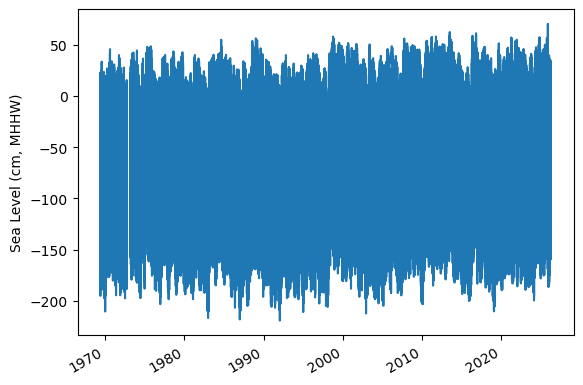

In [6]:
fig, ax = plot_simple_timeseries(
    time_values=rsl.time.values,
    sea_level_cm=rsl.sea_level_mhhw.T.values / 10,
    ylabel=f'Sea Level (cm, {datumname})',
)

glue("TS_full_fig", fig, display=False)


#### Identify epoch for the flood frequency analysis

Now, we'll calculate trend starting from the beginning of the tidal datum analysis period epoch to the last time processed. The  epoch information is given in the datums table. 


In [7]:
#get epoch start time from the epoch in the datumtable
epoch_times = datumtable[datumtable['Name'] == 'Epoch']['Value'].values[0]

#parse epoch times into start time
epoch_start = epoch_times.split(' ')[0]
epoch_start = datetime.datetime.strptime(epoch_start, '%d-%b-%Y')

# and for now, end time the processind end time
epoch_end = epoch_times.split(' ')[2]
epoch_end = datetime.datetime.strptime(epoch_end, '%d-%b-%Y')

# last date is rsl['last_rq_date'].values
data_end = rsl['time'].values[-1]
data_end = pd.to_datetime(data_end)

# start the data at year before epoch_start year on May 1st
data_start = pd.Timestamp(year=epoch_start.year-1, month=5, day=1)
data_start = pd.to_datetime(data_start)

# end the data at April 30th of the year of the last data request
data_end = pd.Timestamp(year=data_end.year, month=4, day=30)
data_end = pd.to_datetime(data_end)

hourly_data = rsl.sel(dict(time=slice(data_start, data_end)))
rsl.close()
hourly_data

glue("startDataDateTime",data_start.strftime('%Y-%m-%d'), display=False)
glue("endDataDateTime",data_end.strftime('%Y-%m-%d'), display=False)
glue("startEpochDateTime",epoch_start.strftime('%Y-%m-%d'), display=False)
glue("endEpochDateTime",epoch_end.strftime('%Y-%m-%d'), display=False)


and plot the hourly time series


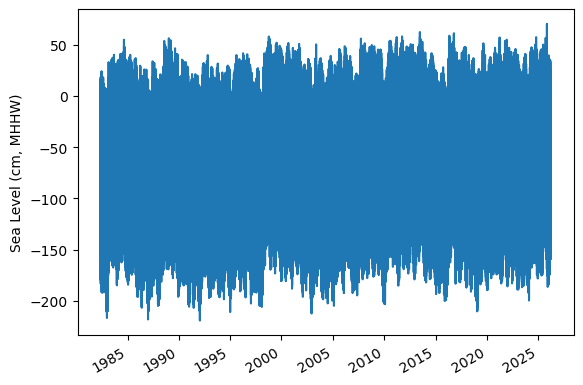

In [8]:
fig, ax = plot_simple_timeseries(
    time_values=hourly_data.time.values,
    sea_level_cm=hourly_data.sea_level_mhhw.T.values / 10,
    ylabel=f'Sea Level (cm, {datumname})',
)

glue("TS_epoch_fig", fig, display=False)


```{glue:figure} TS_epoch_fig
:name: "fig-TS_epoch"

Full time series at {glue:text}`station`,{glue:text}`country` tide gauge for the entire record from {glue:text}`startDataDateTime` to {glue:text}`endDataDateTime`. Note that the sea level is plotted in units of cm, relative to {glue:text}`datumname`.
```


### Assign a Threshold
The threshold used here to determine a flood event is 30 cm above MHHW.
```{note}
Change the threshold and see how things change!
```


In [9]:
threshold = 30 # in cm
glue("threshold",threshold,display=False)


## Calculate Flood Frequency
To analyze flood frequency, we will look for daily maximum sea levels for each day in our dataset, following {cite:t}`thompson_statistical_2019` and others. Then, we can group our data by year and month to visualize temporal patterns in daily SWL exceedance.   


```{glue:figure} histogram_fig
:name: "fig-histogram"
:figclass: margin

Histogram of daily maximum water levels at {glue:text}`station`,{glue:text}`country` tide gauge for the entire record from {glue:text}`startDataDateTime` to {glue:text}`endDataDateTime`, relative to {glue:text}`datumname`. The dashed red line indicates the chosen threshold of {glue:text}`threshold` cm.
```


```{margin}
Note this next code block may take a bit of time. Patience!
```


In [10]:
# Resample the hourly data to daily maximum sea level
SL_daily_max = hourly_data.resample(time='D').max()
static_vars = hourly_data[['station_name', 'station_country','station_country_code', 'datum','lat', 'lon','uhslc_id','gloss_id','ssc_id','last_rq_date']] 

SL_daily_max = SL_daily_max.assign(static_vars)
SL_daily_max


<xarray.Dataset> Size: 321kB
Dimensions:               (time: 16041, record_id: 1)
Coordinates:
  * record_id             (record_id) int64 8B 7
  * time                  (time) datetime64[ns] 128kB 1982-05-01 ... 2026-03-31
Data variables:
    sea_level             (time, record_id) float32 64kB 1.881e+03 ... 2.311e+03
    lat                   (record_id) float32 4B 7.33
    lon                   (record_id) float32 4B 134.5
    station_name          (record_id) <U7 28B 'Malakal'
    station_country       (record_id) <U5 20B 'Palau'
    station_country_code  (record_id) float32 4B 585.0
    uhslc_id              (record_id) int16 2B 7
    gloss_id              (record_id) float32 4B 120.0
    ssc_id                (record_id) |S4 4B b'mala'
    last_rq_date          (record_id) datetime64[ns] 8B 2018-12-31T22:59:59.9...
    datum                 float64 8B 2.16e+03
    sea_level_mhhw        (time, record_id) float64 128kB -279.0 ... 151.0
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (hourly)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:36:55Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

Text(0.5, 1.0, 'Sea Level Daily Maximum Time Series')

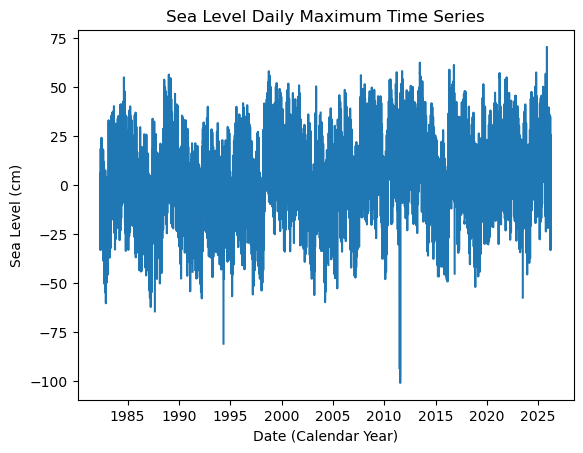

In [11]:
fig, ax = plot_daily_max_timeseries(SL_daily_max)


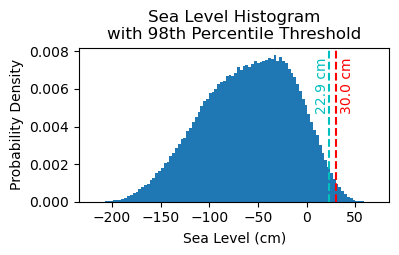

In [12]:
fig, ax, threshold98 = plot_histogram_with_threshold(hourly_data=hourly_data, threshold=threshold)
glue("histogram_fig", fig, display=False)


In [13]:
# Find all days where sea level exceeds the threshold
flood_days_df = SL_daily_max.to_dataframe().reset_index()

flood_days_df['year_storm'] = flood_days_df['time'].dt.year
flood_days_df.loc[flood_days_df['time'].dt.month > 4, 'year_storm'] = flood_days_df['time'].dt.year + 1

#filter flood hours
flood_days_df = flood_days_df[flood_days_df['sea_level_mhhw'] > threshold*10]

flood_days_per_year = flood_days_df.groupby('year_storm').size().reset_index(name='flood_days_count')

all_years = pd.DataFrame({'year_storm': range(flood_days_df['year_storm'].min(), flood_days_df['year_storm'].max() + 1)})

flood_days_per_year = all_years.merge(flood_days_per_year, on='year_storm', how='left').fillna(0)

flood_days_per_year['flood_days_count'] = flood_days_per_year['flood_days_count'].astype(int)


In [14]:
flood_hours_df = hourly_data.to_dataframe().reset_index()

flood_hours_df['year_storm'] = flood_hours_df['time'].dt.year
flood_hours_df.loc[flood_hours_df['time'].dt.month > 4, 'year_storm'] = flood_hours_df['time'].dt.year + 1

#filter flood hours
flood_hours_df = flood_hours_df[flood_hours_df['sea_level_mhhw'] > threshold*10]

flood_hours_per_year = flood_hours_df.groupby('year_storm').size().reset_index(name='flood_hours_count')

all_years = pd.DataFrame({'year_storm': range(flood_hours_df['year_storm'].min(), flood_hours_df['year_storm'].max() + 1)})

flood_hours_per_year = all_years.merge(flood_hours_per_year, on='year_storm', how='left').fillna(0)

flood_hours_per_year['flood_hours_count'] = flood_hours_per_year['flood_hours_count'].astype(int)


Let's have a quick look at the data in flood_hours_per_year:


In [15]:
# show the first few rows of the flood_days_per_year dataframe
flood_days_per_year.head()


,year_storm,flood_days_count
0,1983,1
1,1984,33
2,1985,40
3,1986,9
4,1987,0


## Plot Flood Frequency Counts
Now make a bar plot of the flood days (or hours) through time. We'll begin with a regular bar plot of the counts of flood days. Then we'll add a trend line. Then we'll plot it alongside the ENSO signal, for a visual inspection of any correlating signals. This plot follows {cite:t}center_for_operational_oceanographic_products_and_services_us_sea_2014.

### Simple bar plot
The time axis will be in storm years, and all the bars will be colored by the count of flooding days (more intense blues for more flood days).


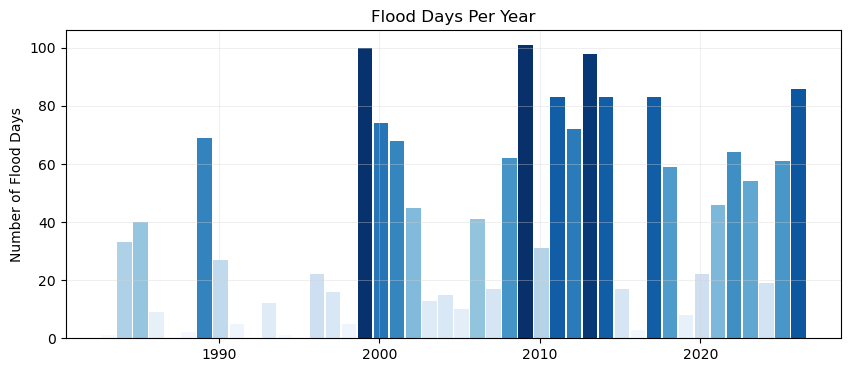

In [16]:
fig, ax, _, _, _ = plot_flood_counts_with_trend(
    flood_count_per_year=flood_days_per_year,
    timescale='days',
)


### Simple bar plot with trend
Now, let's add a trend line to the plot, to see if there are any significant trends in flooding days since the start of our record.


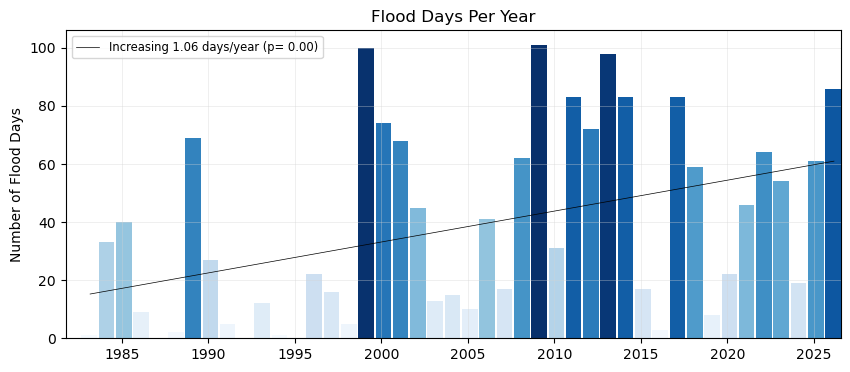

In [17]:
fig, ax, slope_days, p_value_days, trendDays = plot_flood_counts_with_trend(
    flood_count_per_year=flood_days_per_year,
    timescale='days',
)

glue("fig-threshold_counts", fig, display=False)


```{glue:figure} threshold_counts_days_fig
:name: "fig-threshold_counts"

Flood frequency counts above a threshold of {glue:text}`threshold:.3f` cm per year at {glue:text}`station`,{glue:text}`country` tide gauge from {glue:text}`startDataDateTime` to {glue:text}`endDataDateTime`. A trendline is added to the plot, showing a significant (p = {glue:text}`p_value_days:.2f`) increase in flood days per year ({glue:text}`days_per_year_trend:.2f` hours/year).
```


## Plot Flood Frequency Duration 
We'll do the same plot, but this time use our flooding hours data to examine the average duration of flooding events as defined by the threshold. Note that in this calculation these hours need not be continuous (and thus any changes in the scale of the flooding in terms of time-extent is not readily apparent, only the yearly summation.)

```{margin}
As with the previous plot, the colorbar uses a heatmap coloring (darker colors = more counts of hours or days per year). It is normalized by the minimum and maximum of the yearly flood count data.
```


TypeError: plot_trend() got an unexpected keyword argument 'timescale'

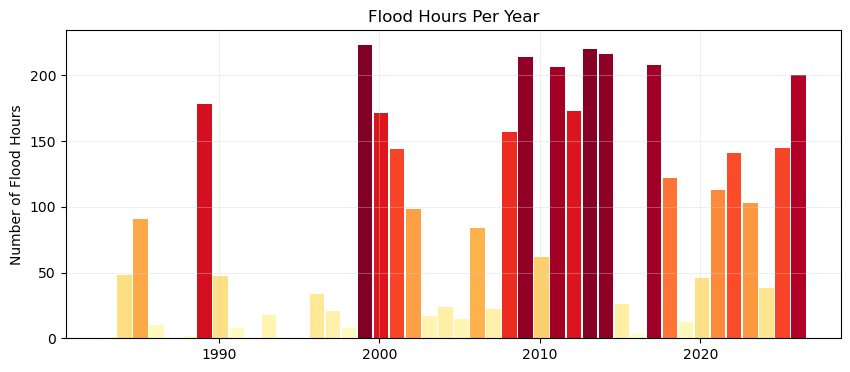

In [18]:
fig, ax, slope_hours, p_value_hours, trendHours = plot_flood_counts_with_trend(
    flood_count_per_year=flood_hours_per_year,
    timescale='hours',
    colors='YlOrRd',
)

glue("hours_per_year_trend", slope_hours, display=False)
glue("p_value_hours", p_value_hours, display=False)
ax.legend(loc='upper left')

glue("duration_fig", fig, display=False)


```{glue:figure} duration_fig
:name: "fig-duration"

Average flood duration in hours above a threshold of {glue:text}`threshold:.0f` cm per year at {glue:text}`station`,{glue:text}`country` tide gauge from {glue:text}`startDataDateTime` to {glue:text}`endDataDateTime`. A trendline is added to the plot, showing a significant (p = {glue:text}`p_value_hours:.2f`) increase in flood days per year ({glue:text}`hours_per_year_trend:.2f` hours/year).
```


## Add the ENSO signal to bar plots


First we'll download our ONI data


In [ ]:
# add nino
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
oni = download_oni_index(p_data)
enso_events = detect_enso_events(oni)


We'll turn this into yearly data by looking at the dominant enso mode for that storm year.


In [ ]:
#turn oni events into yearly dataframe
enso_yearly = enso_events.groupby('year_storm')['ONI Mode'].agg(get_dominant_enso).to_frame(name='ONI Mode')
enso_yearly['ONI'] = enso_events.groupby('year_storm')['ONI'].mean()
enso_yearly


,ONI Mode,ONI
year_storm,,
1950,Neutral,-0.337500
1951,El Nino,0.670833
1952,El Nino,0.237500
1953,El Nino,0.586667
1954,La Nina,-0.697500
...,...,...
2021,La Nina,-0.761667
2022,La Nina,-0.700833
2023,El Nino,1.330000


In [ ]:
# add enso events to flood_days_per_year
flood_days_per_year = flood_days_per_year.merge(enso_yearly, on='year_storm', how='left')
flood_days_per_year.head()


,year_storm,flood_days_count,ONI Mode,ONI
0,1983,1,El Nino,-0.246667
1,1984,33,La Nina,-0.643333
2,1985,40,La Nina,-0.434167
3,1986,9,El Nino,0.745000
4,1987,0,El Nino,1.005833


### Plot the ONI signal through time
We'll color it by El Nino/La Nina


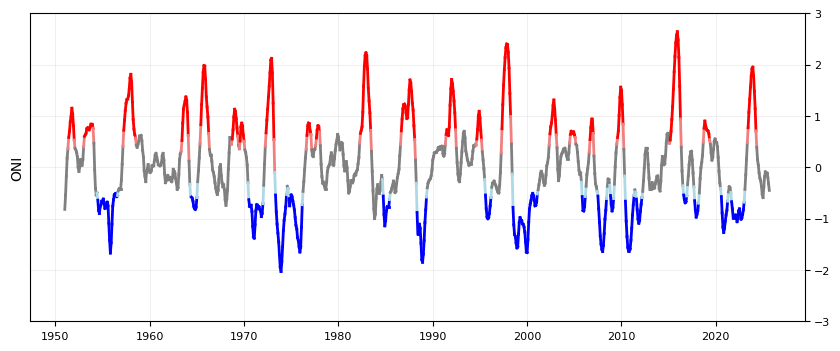

In [ ]:
fig, ax = plot_oni_only(enso_events)


### Plot combined flood days with ENSO signal 
Now we'll combine our previous plots into one.
<!-- The flood frequency counts are defined as the number of time periods that exceed a given threshold within a year. This plot follows {cite:t}`center_for_operational_oceanographic_products_and_services_us_sea_2014`. -->


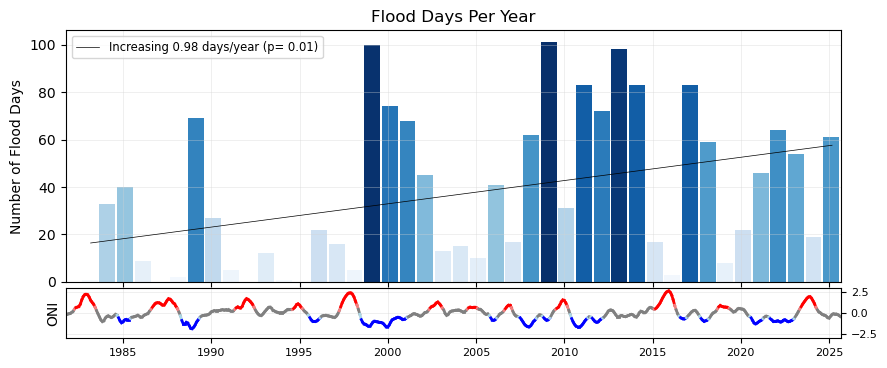

In [ ]:
fig, axes, slope_days, p_value_days = plot_flood_counts_with_oni(
    flood_days_per_year=flood_days_per_year,
    enso_events=enso_events,
)

glue("day_per_year_trend", slope_days, display=False)
glue("p_value_days", p_value_days, display=False)
glue("fig-threshold_counts_enso", fig, display=False)

fig.savefig(
    site_output_dir / build_output_filename('SL_FloodFrequency_threshold_counts_days', site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches='tight',
)


```{glue:figure} threshold_counts_days_fig_enso
:name: "fig-threshold_counts_enso"

Flood frequency counts above a threshold of {glue:text}`threshold:.0f` cm per year at {glue:text}`station`,{glue:text}`country` tide gauge from {glue:text}`startDataDateTime` to {glue:text}`endDataDateTime`. The bottom subplot shows the ONI index for the same time period, with red corresponding to El Nino conditions (ONI>0.5) and blue corresponding to La Nina conditions (ONI<-0.5). A trendline is added to the plot, showing a significant (p = {glue:text}`p_value_days:.2f`) increase in flood days per year ({glue:text}`days_per_year_trend:.2f` days/year).
```


## Create a Table

Next we'll calculate some summary statistics over the POR at the tide station/s, for both Frequency and Duration.

We will include the trendline statistics from our previous plots.


In [ ]:
# Calculate the total number of days/hours exceeding the threshold
total_flood_days = flood_days_per_year['flood_days_count'].sum()
total_flood_hours = flood_hours_per_year['flood_hours_count'].sum()

# Calculate the average number of flood days and hours per year
average_flood_days_per_year = total_flood_days / len(flood_days_per_year)
average_flood_hours_per_year = flood_hours_per_year['flood_hours_count'].mean()

# Find the maximum number of flood days in a single year
max_flood_days = flood_days_per_year['flood_days_count'].max()
max_flood_days_year = flood_days_per_year.loc[flood_days_per_year['flood_days_count'].idxmax(), 'year_storm']

# Find the maximum number of flood hours in a single year
max_flood_hours = flood_hours_per_year['flood_hours_count'].max()
max_flood_hours_year = flood_hours_per_year.loc[flood_hours_per_year['flood_hours_count'].idxmax(), 'year_storm']

# calculate the absolute percent change over the entire period using the first and last part of the trend
percent_change_days = (trendDays[-1]-trendDays[0])/trendDays[0]*100
percent_change_hours = (trendHours[-1]-trendHours[0])/trendHours[0]*100


Now we'll generate a table with this information, which will be saved as a .csv in the output directory specified at the top of this notebook.


In [ ]:
# Create a dataframe for statistics
summary_stats = [
    ('Total Flood Days', int(total_flood_days)),
    ('Average Flood Days per Year', int(average_flood_days_per_year)),
    ('Max Flood Days in a Single Year', int(max_flood_days)),
    ('Year of Max Flood Days', int(max_flood_days_year)),
    ('Total Flood Hours', int(total_flood_hours)),
    ('Average Flood Hours per Year', int(average_flood_hours_per_year)),
    ('Max Flood Hours in a Single Year', int(max_flood_hours)),
    ('Year of Max Flood Hours', int(max_flood_hours_year)),
    ('Percent Change in Flood Days', int(percent_change_days)),
    ('Percent Change in Flood Hours', int(percent_change_hours)),
    ('Trend in Flood Days (days/year)', round(slope_days, 2)),
    ('P-value for Flood Days Trend', round(p_value_days, 2)),
    ('Trend in Flood Hours (hours/year)', round(slope_hours, 2)),
    ('P-value for Flood Hours Trend', round(p_value_hours, 2))
]

# Convert the list of tuples to a pandas DataFrame
summary_stats_df = pd.DataFrame(summary_stats, columns=['Statistic', 'Value'])

# Display the DataFrame
summary_stats_df


,Statistic,Value
0,Total Flood Days,1591.00
1,Average Flood Days per Year,37.00
2,Max Flood Days in a Single Year,101.00
3,Year of Max Flood Days,2009.00
4,Total Flood Hours,3470.00
5,Average Flood Hours per Year,80.00
6,Max Flood Hours in a Single Year,223.00
7,Year of Max Flood Hours,1999.00
8,Percent Change in Flood Days,251.00
9,Percent Change in Flood Hours,321.00


## Create a sub-annual table
Here we'll turn our 'flooding days' into a dataframe to look at monthly changes through time.


In [ ]:
import calendar
# Make a dataframe with years as rows and months as columns
df = SL_daily_max.to_dataframe().reset_index()
df['flood_day'] = df['sea_level_mhhw'] > threshold*10

# keep only the flood day and time columns
df = df[['time', 'flood_day']]

df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

# adjust for storm year
df.loc[df['month'] > 4, 'year'] = df.loc[df['month'] > 4, 'year'] + 1

# drop original time column
df = df.drop(columns=['time'])

# sum the number of flood days in each month for each storm year
df = df.groupby(['year', 'month']).sum()

# pivot the table
df = df.pivot_table(index='year', columns='month', values='flood_day')

# remove first and last rows (partial years)
# df = df.iloc[1:-1]

# rename year to Storm Year
df.index.name = 'Storm Year'

#define reordered months (for storm year, May to April)
month_order = [5,6,7,8,9,10,11,12,1,2,3,4]
month_names = [calendar.month_abbr[i] for i in month_order]
# rename months to month names
df = df[month_order]
df.columns = month_names

# add a column for the total number of flood days in each year
df['Annual'] = df.sum(axis=1)



# add a row for the total number of flood days in each month, normalized the total flood days (last row, last column)
df.loc['Monthly Total (%)'] = df.sum()
df.loc['Monthly Total (%)'] = 100*df.loc['Monthly Total (%)']/df.loc['Monthly Total (%)', 'Annual']

# station_name = SL_daily_max['station_name'] +', ' + SL_daily_max['station_country']

tableTitle = station_name + ': Days Exceeding ' + str(threshold) + ' cm above MHHW'
# Apply background gradient and add a title with larger text
styled_df = df.style.background_gradient(
    cmap='Purples', axis=None, subset=(df.index[:-1], df.columns[:-1])
).format("{:.0f}").background_gradient(
    cmap='Grays', axis=None, subset=(df.index[-1], df.columns[:-1])
).format("{:.0f}").set_caption(tableTitle).set_table_styles([
    {
        'selector': 'caption',
        'props': [('font-size', '16px'), ('margin-bottom', '10px')]
    }
])

styled_df


,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Jan,Feb,Mar,Apr,Annual
Storm Year,,,,,,,,,,,,,
1983,0,0,0,0,0,0,0,0,0,1,0,0,1
1984,1,5,5,4,3,2,1,0,2,3,1,6,33
1985,5,1,4,9,6,3,4,0,0,0,3,5,40
1986,3,2,0,0,2,2,0,0,0,0,0,0,9
1987,0,0,0,0,0,0,0,0,0,0,0,0,0
1988,0,1,0,1,0,0,0,0,0,0,0,0,2
1989,0,0,4,8,6,7,4,3,17,7,7,6,69
1990,4,0,2,6,5,4,4,0,0,0,0,2,27
1991,3,1,0,0,1,0,0,0,0,0,0,0,5


We can also make this in plot form (instead of a styled dataframe).


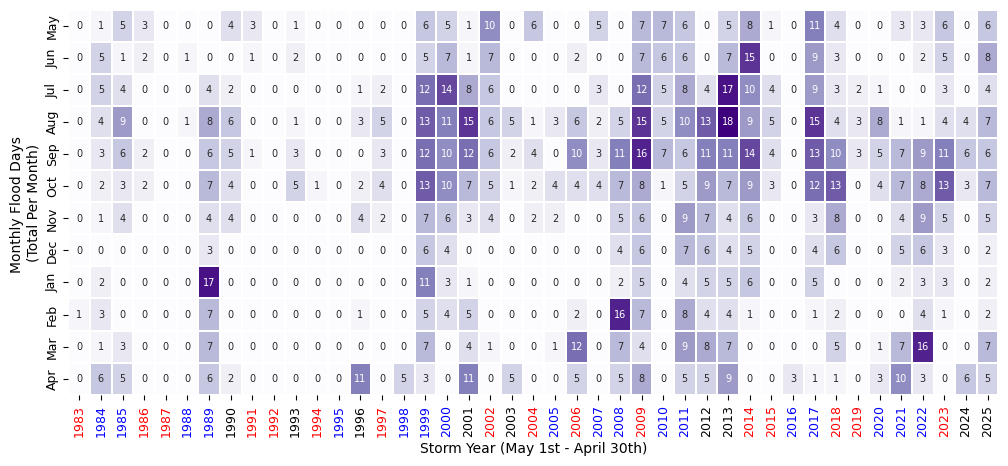

In [ ]:
fig, ax = plot_flood_days_heatmap(df=df, flood_days_per_year=flood_days_per_year)


## Plot Monthly Frequency Bar Plot
We can also make this information into a bar plot to compare the monthly contribution visually. This code is made so the bar plot can be plotted in either vertical or horizontal bars. This will come up later when we combine our tables and plots into one summary figure.


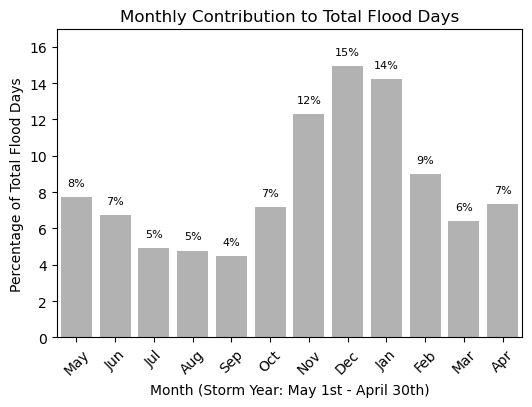

In [ ]:
fig, ax = plot_monthly_contribution_vertical(df=df, month_names=month_names)


We can also make a nice table for printed reports.


In [ ]:
#make a pretty pdf of the table with great_tables
from great_tables import GT,html

dfGT = df.copy()
dfGT['Storm Year'] = df.index

# put the year column first
cols = dfGT.columns.tolist()
cols = cols[-1:] + cols[:-1]
dfGT = dfGT[cols]
dfGT.reset_index(drop=True, inplace=True)


# Create a GreatTable object
table = (GT(dfGT)
.fmt_number(columns=calendar.month_abbr[1:13], decimals=0)
.fmt_number(columns=['Annual'], decimals=0)
.tab_header(title = 'Days Exceeding 30 cm above MHHW', subtitle = station_name)
.data_color(domain = [0,20],
            columns=calendar.month_abbr[1:13],
            rows = list(range(len(dfGT)-1)),
            palette=["white", "lightblue"])
.data_color(domain = [0,20],
            columns=calendar.month_abbr[1:13],
            rows = [-1],
            palette=["white", "purple"])
.opt_table_outline(style='solid', width='3px', color='white')
)

# save table as png
tableName = station_name + '_flood_days_intra_annual.png'
savePath = os.path.join(output_dir, tableName)

# set size of table

# replace any commas or spaces with underscores
# savePath = savePath.replace(' ', '_')
# table.save(savePath)

# Load Image
from IPython.display import Image
imgTable = Image(filename=savePath)

# Glue the image with a name
glue("imgTable", imgTable, display=False)


In [ ]:
# Define the decades for analysis
decades = [(1983, 1993), (1993, 2003), (2003, 2013), (2013, 2023)]

# Initialize lists to store results
total_flood_days_list = []
average_flood_days_per_year_list = []
percent_increase_days_per_year_list = [0]  # First decade has no previous data for comparison

# Calculate statistics for each decade
for i, (start_year, end_year) in enumerate(decades):
    # Filter the dataframe for the current decade
    flood_days_decade = flood_days_per_year[(flood_days_per_year['year_storm'] >= start_year) & (flood_days_per_year['year_storm'] <= end_year)]
    sum_flood_days_decade = flood_days_decade['flood_days_count'].sum()
    avg_flood_days_decade = sum_flood_days_decade / len(flood_days_decade)
    
    # Append results to lists
    total_flood_days_list.append(sum_flood_days_decade)
    average_flood_days_per_year_list.append(np.round(avg_flood_days_decade,0))
    
    # Calculate percent increase for subsequent decades
    if i > 0:
        prev_avg_flood_days = average_flood_days_per_year_list[0]
        percent_increase = np.round((avg_flood_days_decade - prev_avg_flood_days) / prev_avg_flood_days * 100, 1)
        percent_increase_days_per_year_list.append(percent_increase)

# Create a dataframe for decadal statistics
decadal_stats = pd.DataFrame({
    'decade': ['1983-1993', '1993-2003', '2003-2013', '2013-2023'],
    'total_flood_days': total_flood_days_list,
    'average_flood_days_per_year': average_flood_days_per_year_list,
    'percent_increase_days_per_year': percent_increase_days_per_year_list
})

decadal_stats


,decade,total_flood_days,average_flood_days_per_year,percent_increase_days_per_year
0,1983-1993,198,18.0,0.0
1,1993-2003,356,32.0,79.8
2,2003-2013,543,49.0,174.2
3,2013-2023,537,49.0,171.2


## Join plots and tables


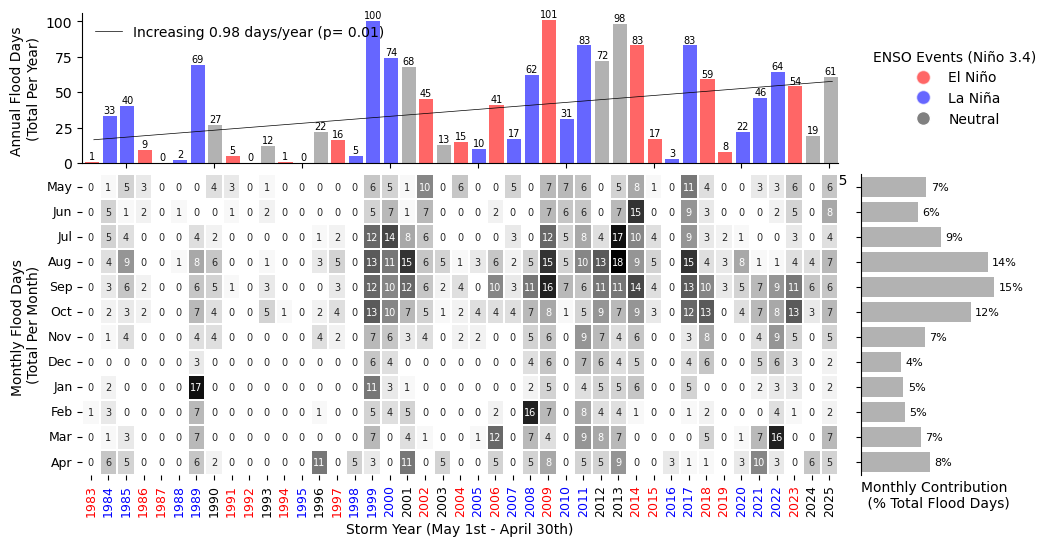

In [ ]:
fig, axs, slope_days, p_value_days = plot_flood_matrix_summary(
    df=df,
    flood_days_per_year=flood_days_per_year,
)

fig.savefig(site_output_dir / build_output_filename('SL_FloodFrequency_threshold_counts_heatmap', site_name, site_lon, site_lat), bbox_inches='tight')
plt.savefig(site_output_dir / build_output_filename('F11_Minor_flood_matrix', site_name, site_lon, site_lat), dpi=300, bbox_inches='tight')


```{glue:figure} imgTable
:name: "imgTable"
:scale: 40%
Monthly and Annual tally of flooding days at {glue:text}`station`, {glue:text}`country` .
```


## Citations

```{bibliography}
:style: alpha
:filter: docname in docnames
```


In [ ]:
# Save structured flood-frequency outputs for this site
ff_payload = {
    'site_name': site_name,
    'uhslc_id': int(uhslc_id),
    'threshold_cm': float(threshold),
}

if 'flood_days_per_year' in globals():
    save_table_to_csv(
        flood_days_per_year,
        site_output_dir,
        build_output_filename('SL_flood_days_per_year', site_name, site_lon, site_lat, ext='csv'),
        index=False,
    )
    ff_payload['flood_days_per_year_stats'] = {
        'n_years': int(len(flood_days_per_year)),
        'mean_days': float(flood_days_per_year['flood_days_count'].mean()),
        'max_days': float(flood_days_per_year['flood_days_count'].max()),
    }

if 'flood_hours_per_year' in globals():
    save_table_to_csv(
        flood_hours_per_year,
        site_output_dir,
        build_output_filename('SL_flood_hours_per_year', site_name, site_lon, site_lat, ext='csv'),
        index=False,
    )
    ff_payload['flood_hours_per_year_stats'] = {
        'n_years': int(len(flood_hours_per_year)),
        'mean_hours': float(flood_hours_per_year['flood_hours_count'].mean()),
        'max_hours': float(flood_hours_per_year['flood_hours_count'].max()),
    }

for var_name in ['slope_days', 'p_value_days', 'slope_hours', 'p_value_hours']:
    if var_name in globals():
        ff_payload[var_name] = float(globals()[var_name])

save_dict_json(
    ff_payload,
    site_output_dir,
    build_output_filename('SL_flood_frequency_summary_metrics', site_name, site_lon, site_lat, ext='json'),
)
